<a href="https://colab.research.google.com/github/pop756/Quantum_KAN/blob/EMT/Real_backend.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
""" 
!git clone -b EMT https://github.com/pop756/Quantum_KAN.git
%cd Quantum_KAN
!pip install -r requirements.txt """

' \n!git clone -b EMT https://github.com/pop756/Quantum_KAN.git\n%cd Quantum_KAN\n!pip install -r requirements.txt '

In [2]:
# Initialize your account
from qiskit_ibm_runtime import QiskitRuntimeService
from qiskit_aer import AerSimulator
from qiskit.circuit.library import RealAmplitudes, EfficientSU2

service = QiskitRuntimeService(
    channel="ibm_quantum",
    instance="ibm-q-skku/skku/skku-students",
    token="06f802eeac992c43c4106753d7c5fc31414a13eb7d91c99d67fb49cc50569e5b4b011f20c71b9607a07cb43ecc7044557c699022db91d1685ba4c886d5886854",
)
backend = service.backend('ibm_osaka')



In [3]:
from functions.Train_ZNE import update_pulse
import json

with open('./brussels_ecr_data_2.json','r') as file:
    config_list = json.load(file)
for config in config_list:
    config['amp'] = config['x_amp_3']
update = update_pulse(backend,config_list)

In [4]:
config_list

[{'init': [100, 99],
  'cr_amp': 0.18638616218784648,
  'cr_angle': 1.594171377843993,
  'x_amp_1': 0.03904507949409433,
  'x_amp_2': 0.04407189876491644,
  'x_amp_3': 0.04909871803573856,
  'offset': 0,
  'beta': -0.10105057054394104,
  'amp': 0.04909871803573856}]

In [5]:
backend_update = update.update_ecr_real()

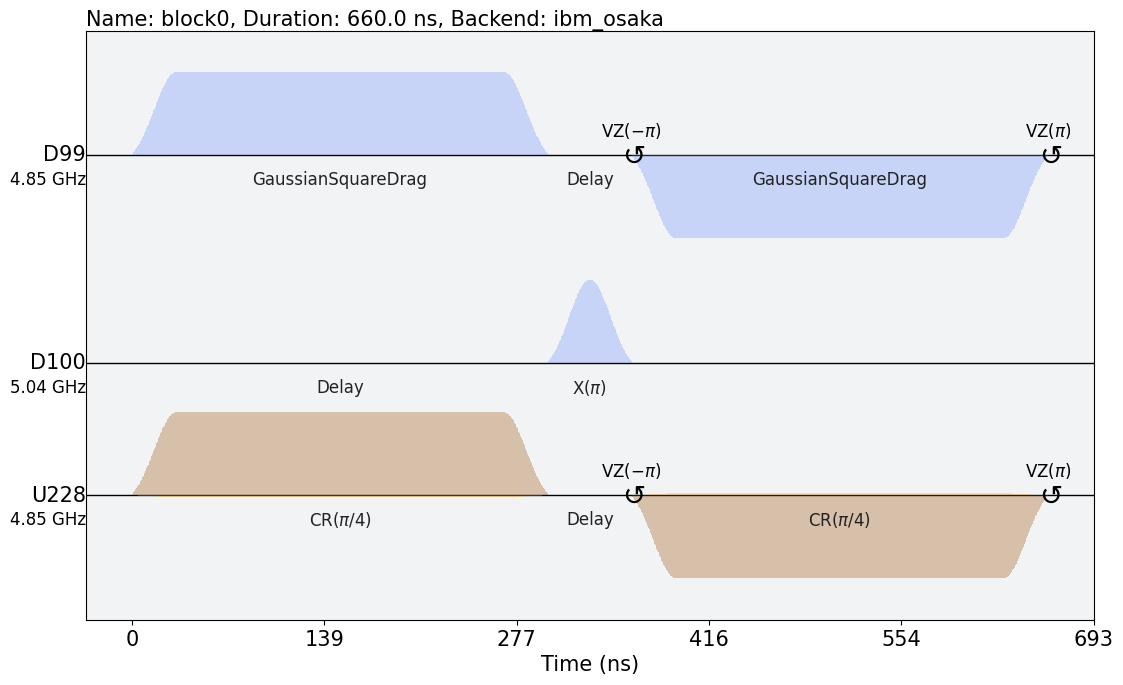

In [6]:
from qiskit import schedule

backend_update.target['ecr'][(100,99)].calibration.draw(backend = backend)

In [9]:
import numpy as np
from qiskit_experiments.library import StandardRB, InterleavedRB
from qiskit_experiments.framework import ParallelExperiment, BatchExperiment
import qiskit.circuit.library as circuits
from qiskit_experiments.library import StandardRB, InterleavedRB


lengths = np.arange(1, 200, 30)
num_samples = 10
seed = 1010

data_list_ecr_1 = []
# Run a 1-qubit RB experiment on qubits 1, 2 to determine the error-per-gate of 1-qubit gates
for config in config_list:
    qubit = tuple(config['init'])
    exp = StandardRB(qubit, lengths_2_qubit, num_samples=num_samples, seed=seed)
    expdata_2q_1_2 = exp.run(backend_update).block_for_results()
    data_list_ecr_1.append(expdata_2q_1_2)

Job data not added for errored job [Job ID: ctr4qyzx7b5g0080v9r0]
Error message: Job ctr4qyzx7b5g0080v9r0 has failed:
Too large of job payload being loaded. Reduce the length of the program data being loaded. 


In [21]:
backend.target['ecr'][(100,99)].calibration

Schedule((0, Play(GaussianSquare(duration=600, sigma=32, width=472, amp=0.03985760624282706, angle=0.08727792347311986, name='CR90p_d99_u228'), DriveChannel(99), name='CR90p_d99_u228')), (0, Play(GaussianSquare(duration=600, sigma=32, width=472, amp=0.19097799892254036, angle=1.594171377843993, name='CR90p_u228'), ControlChannel(228), name='CR90p_u228')), (600, Play(Drag(duration=120, sigma=30, beta=0.029268411794595522, amp=0.20571529316749754, angle=0.0, name='Xp_d100'), DriveChannel(100), name='Xp_d100')), (720, Play(GaussianSquare(duration=600, sigma=32, width=472, amp=0.03985760624282706, angle=-3.0543147301166735, name='CR90m_d99_u228'), DriveChannel(99), name='CR90m_d99_u228')), (720, Play(GaussianSquare(duration=600, sigma=32, width=472, amp=0.19097799892254036, angle=-1.5474212757458004, name='CR90m_u228'), ControlChannel(228), name='CR90m_u228')), name="ecr")

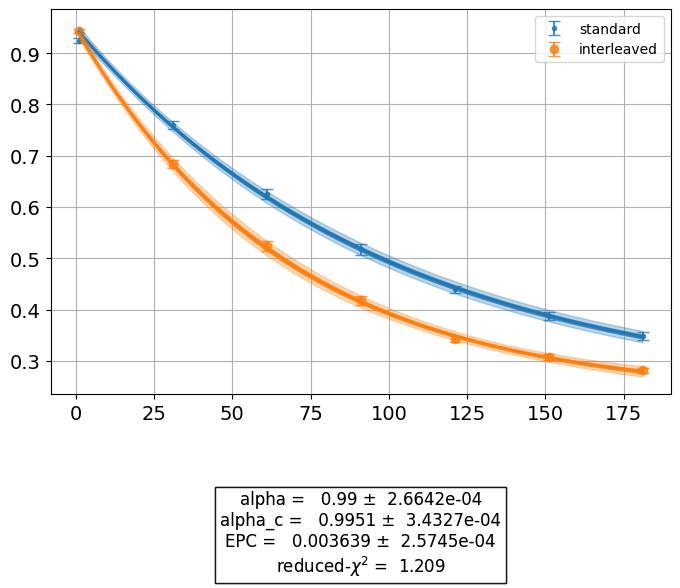

AnalysisResult
- name: @Parameters_InterleavedRBAnalysis
- value: CurveFitResult:
 - fitting method: least_squares
 - number of sub-models: 2
  * F_standard(x) = a * alpha ** x + b
  * F_interleaved(x) = a * (alpha_c * alpha) ** x + b
 - success: True
 - number of function evals: 30
 - degree of freedom: 10
 - chi-square: 12.094278616438297
 - reduced chi-square: 1.2094278616438296
 - Akaike info crit.: 5.951452373642855
 - Bayesian info crit.: 8.507681692103889
 - init params:
  * a = 0.6937818952314665
  * alpha = 0.9893804946870867
  * b = 0.25
  * alpha_c = 0.9936337053931761
 - fit params:
  * a = 0.7166137243240381 ± 0.007285264176650856
  * alpha = 0.9899801252075059 ± 0.0002664171598930391
  * b = 0.23203090344562652 ± 0.00731984879202724
  * alpha_c = 0.9951480571689983 ± 0.00034326803769575036
 - correlations:
  * (a, b) = -0.8865376688736961
  * (alpha, b) = -0.7995850224401624
  * (b, alpha_c) = -0.6879194693989454
  * (alpha, alpha_c) = 0.30615566922980925
  * (a, alpha_c)

In [ ]:
lengths = np.arange(1, 200, 15)
num_samples = 10
seed = 1010

for config in config_list:
    qubits = tuple(config['init'])
    # The interleaved gate is the CX gate
    int_exp2 = InterleavedRB(
        circuits.ECRGate(), qubits, lengths, num_samples=num_samples, seed=seed)

    int_expdata2 = int_exp2.run(backend).block_for_results()
    int_results2 = int_expdata2.analysis_results()
    # View result data
    display(int_expdata2.figure(0))
    for result in int_results2:
        print(result)

In [22]:
lengths = np.arange(1, 200, 30)
num_samples = 10
seed = 1010

for config in config_list:
    qubits = tuple(config['init'])
    # The interleaved gate is the CX gate
    int_exp2 = InterleavedRB(
        circuits.ECRGate(), qubits, lengths, num_samples=num_samples, seed=seed)

    int_expdata2 = int_exp2.run(backend_update).block_for_results()
    int_results2 = int_expdata2.analysis_results()
    # View result data
    display(int_expdata2.figure(0))
    for result in int_results2:
        print(result)

In [19]:
int_expdata2.analysis_results()

[]

In [10]:
data_list_ecr_1[0].figure(0)

ExperimentEntryNotFound: 'Figure index 0 out of range.'

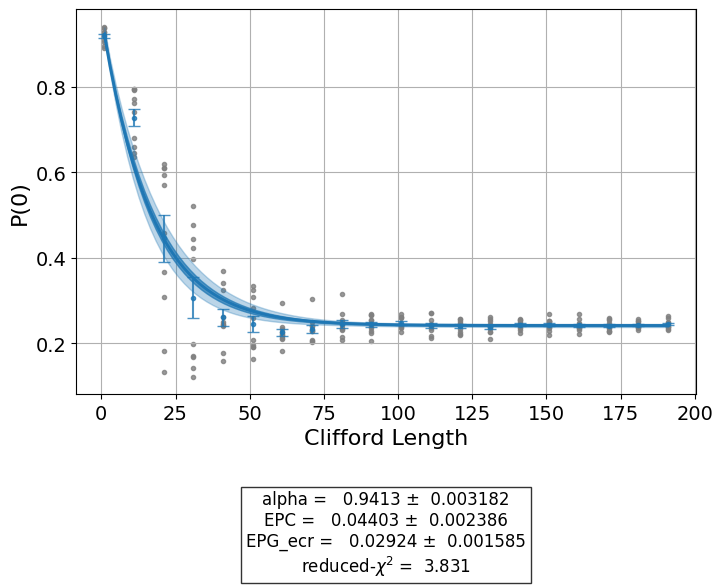

In [71]:
data_list_ecr_1[0].figure(0)

In [20]:
import numpy as np
from qiskit_experiments.library import StandardRB, InterleavedRB
from qiskit_experiments.framework import ParallelExperiment, BatchExperiment
import qiskit.circuit.library as circuits


backend_ecr = zne_osaka.ZNE_pulse_ecr(1.2)
# For simulation
from qiskit_aer import AerSimulator

lengths_2_qubit = np.arange(1, 200,10)
num_samples = 10
seed = 1010
qubits = X_dict.keys()
data_list_ecr_1_2 = []
# Run a 1-qubit RB experiment on qubits 1, 2 to determine the error-per-gate of 1-qubit gates
for qubit in qubits:
    exp = StandardRB(qubit, lengths_2_qubit, num_samples=num_samples, seed=seed)
    expdata_2q_1_2 = exp.run(backend_ecr).block_for_results()
    data_list_ecr_1_2.append(expdata_2q_1_2)

In [76]:
import numpy as np
from qiskit_experiments.library import StandardRB, InterleavedRB
from qiskit_experiments.framework import ParallelExperiment, BatchExperiment
import qiskit.circuit.library as circuits


backend_ecr = zne_osaka.ZNE_pulse_error(1)
# For simulation
from qiskit_aer import AerSimulator

lengths_2_qubit = np.arange(1, 200,10)
num_samples = 10
seed = 1010
qubits = X_dict.keys()
data_list_error_1_high = []
# Run a 1-qubit RB experiment on qubits 1, 2 to determine the error-per-gate of 1-qubit gates
for qubit in qubits:
    exp = StandardRB_error(qubit, lengths_2_qubit, num_samples=num_samples, seed=seed)
    expdata_2q_1_2 = exp.run(backend_ecr).block_for_results()
    data_list_error_1_high.append(expdata_2q_1_2)

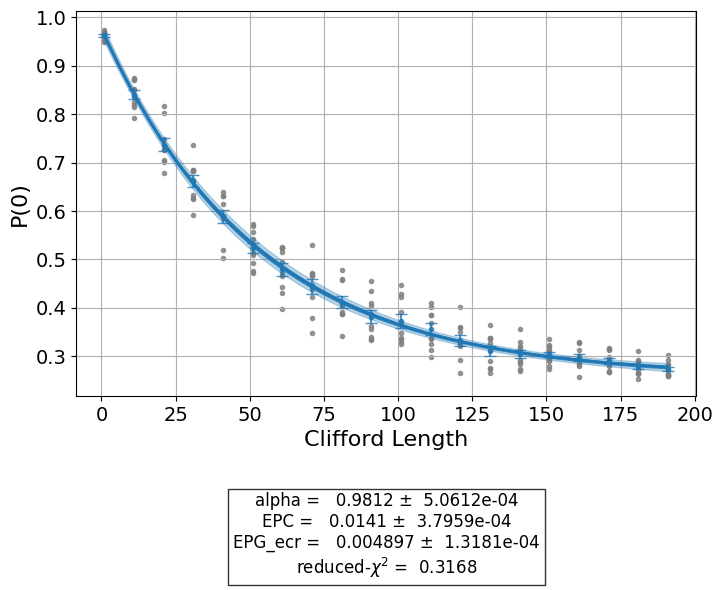

In [87]:
data_list_error_1_high[6].figure(0)

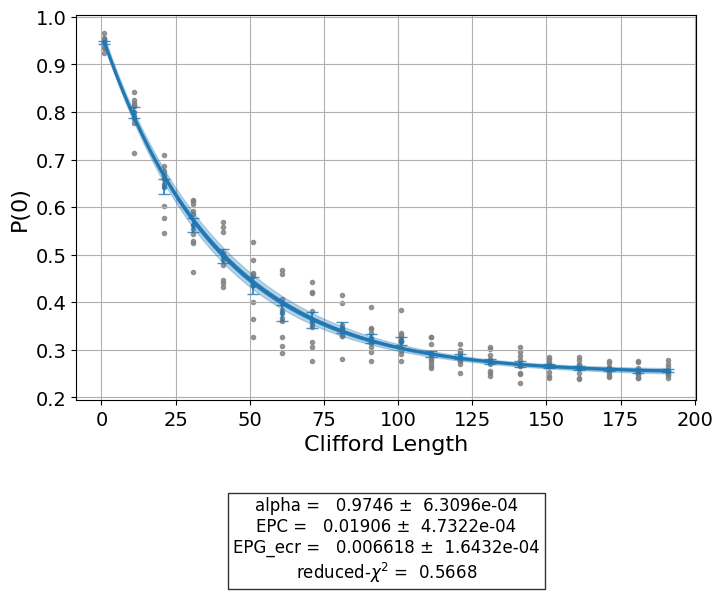

In [86]:
data_list_error_1[6].figure(0)

In [17]:
import numpy as np
from qiskit_experiments.library import StandardRB, InterleavedRB
from qiskit_experiments.framework import ParallelExperiment, BatchExperiment
import qiskit.circuit.library as circuits
from qiskit_experiments.library.randomized_benchmarking.standard_rb import StandardRB_error

backend_ecr = zne_osaka.ZNE_pulse_error(1.2)
# For simulation
from qiskit_aer import AerSimulator

lengths_2_qubit = np.arange(1, 200,10)
num_samples = 10
seed = 1010
qubits = X_dict.keys()
data_list_error_1_2 = []
# Run a 1-qubit RB experiment on qubits 1, 2 to determine the error-per-gate of 1-qubit gates
for qubit in qubits:
    exp = StandardRB_error(qubit, lengths_2_qubit, num_samples=num_samples, seed=seed)
    expdata_2q_1_2 = exp.run(backend_ecr).block_for_results()
    data_list_error_1_2.append(expdata_2q_1_2)

In [18]:
import numpy as np
from qiskit_experiments.library import StandardRB, InterleavedRB
from qiskit_experiments.framework import ParallelExperiment, BatchExperiment
import qiskit.circuit.library as circuits
from qiskit_experiments.library.randomized_benchmarking.standard_rb import StandardRB_error

backend_ecr = zne_osaka.ZNE_pulse_error(1.4)
# For simulation
from qiskit_aer import AerSimulator

lengths_2_qubit = np.arange(1, 200,10)
num_samples = 10
seed = 1010
qubits = X_dict.keys()
data_list_error_1_4 = []
# Run a 1-qubit RB experiment on qubits 1, 2 to determine the error-per-gate of 1-qubit gates
for qubit in qubits:
    exp = StandardRB_error(qubit, lengths_2_qubit, num_samples=num_samples, seed=seed)
    expdata_2q_1_2 = exp.run(backend_ecr).block_for_results()
    data_list_error_1_4.append(expdata_2q_1_2)

In [19]:
import numpy as np
from qiskit_experiments.library import StandardRB, InterleavedRB
from qiskit_experiments.framework import ParallelExperiment, BatchExperiment
import qiskit.circuit.library as circuits
from qiskit_experiments.library.randomized_benchmarking.standard_rb import StandardRB_error

backend_ecr = zne_osaka.ZNE_pulse_error(1.6)
# For simulation
from qiskit_aer import AerSimulator

lengths_2_qubit = np.arange(1, 200,10)
num_samples = 10
seed = 1010
qubits = X_dict.keys()
data_list_error_1_6 = []
# Run a 1-qubit RB experiment on qubits 1, 2 to determine the error-per-gate of 1-qubit gates
for qubit in qubits:
    exp = StandardRB_error(qubit, lengths_2_qubit, num_samples=num_samples, seed=seed)
    expdata_2q_1_2 = exp.run(backend_ecr).block_for_results()
    data_list_error_1_6.append(expdata_2q_1_2)

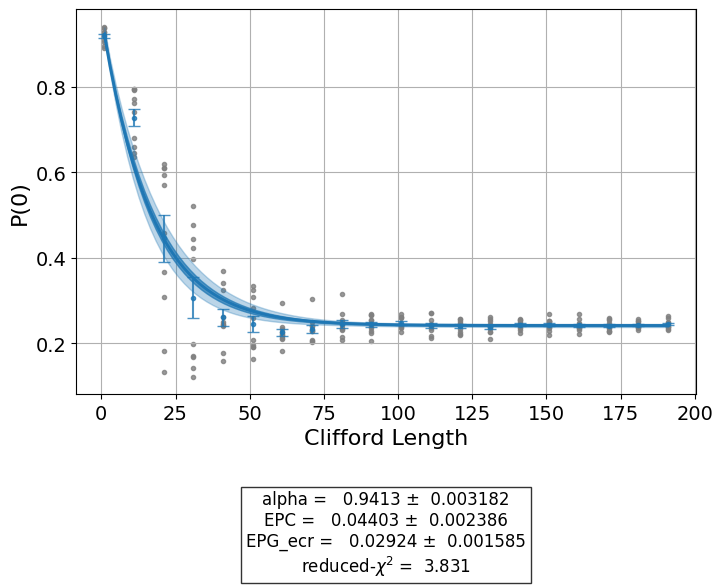

In [52]:
data_list_ecr_1[0].figure(0)

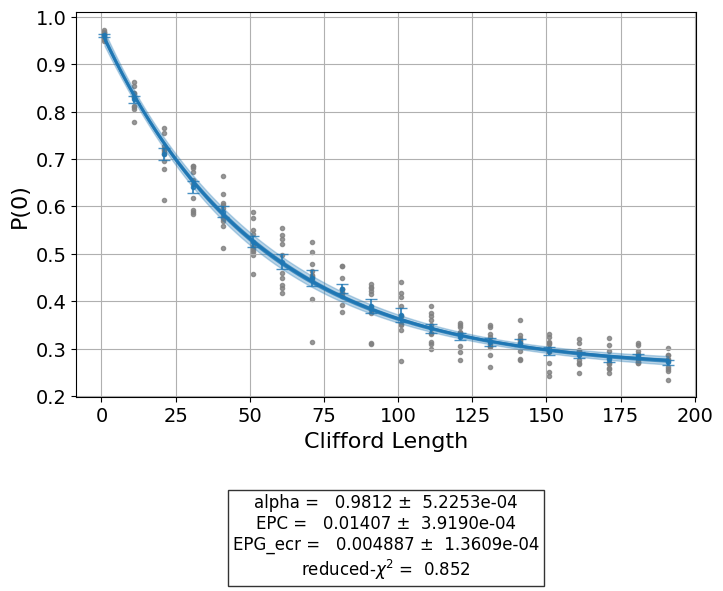

In [58]:
data_list_error_1[4].figure(0)

In [ ]:
def remove_ecr_gates(circuit):
    new_circuit = QuantumCircuit(circuit.num_qubits)
    for instr, qargs, cargs in circuit.data:

        if instr.name == "measure":
            continue

        elif instr.name == "cx" and qargs[0]._index == 0:
            new_circuit.x(1)

        elif instr.name != "cx":
            new_circuit.append(instr, qargs, cargs)
    return new_circuit

In [ ]:
def get_forward(circuit):
    new_circuit = QuantumCircuit(circuit.num_qubits)
    index = 0
    for instr, qargs, cargs in circuit.data:
        if instr.name == "barrier":
            index += 1
            continue
    index_forward = 0
    for instr, qargs, cargs in circuit.data:
        if (index - 1) == index_forward:
            break
        new_circuit.append(instr, qargs, cargs)
        if instr.name == "barrier":
            index_forward += 1
    return new_circuit


def get_forward_inverse(circuit):
    circuit_forward = get_forward(circuit)
    circuit_reverse = circuit_forward.inverse()
    circuit_forward.append(circuit_reverse, [0, 1])
    return circuit_forward

In [ ]:
import qiskit.circuit.library as circuits
from qiskit.primitives import Sampler

# from functions.Train_ZNE import remove_ecr_gates


exp = StandardRB_error(physical_qubits=(0, 1), lengths=[5], num_samples=5, seed=52)
c = exp.circuits()[2]

sampler = Sampler()
#c = get_forward_inverse(c)
#c.measure_all()
job = sampler.run(c)
job.result()

SamplerResult(quasi_dists=[{0: 0.999999999999992}], metadata=[{}])

In [ ]:
from qiskit import transpile
from qiskit import QuantumCircuit

c = remove_ecr_gates(c)
c = transpile(c, basis_gates=["y", "x", "h", "s", "z", "cx"])



c.measure_all()

In [ ]:
sampler = Sampler()
job = sampler.run(c)
job.result()

SamplerResult(quasi_dists=[{0: 0.999999999999994}], metadata=[{}])